# LSTM Input Data Diagnostics
Investigates the sequence data passed to the LSTM — scales, distributions, outliers, and the root cause of systematic underprediction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

SEQ_DIR = Path('../data/processed/sequences')
PROCESSED_DIR = Path('../data/processed')

TEMPORAL_COLS = [
    'num_orders', 'checkout_price', 'base_price', 'discount_rate', 'log_checkout_price',
    'emailer_for_promotion', 'homepage_featured', 'email_x_discount', 'homepage_x_discount',
    'week_number', 'week_of_year_sin', 'week_of_year_cos',
    'center_week_count', 'center_cat_week_count', 'city_meal_week_count',
    'meal_week_count', 'region_meal_week_count', 'type_meal_week_count',
    'center_week_price_rank', 'meal_week_price_rank',
    'ewm_alpha05', 'ewm_span10', 'ewm_span13', 'ewm_span26',
    'rolling_mean_4w', 'rolling_std_4w', 'rolling_min_4w', 'rolling_max_4w',
    'rolling_mean_8w', 'rolling_std_8w', 'rolling_min_8w', 'rolling_max_8w',
]

DEMAND_COLS = [
    'num_orders', 'ewm_alpha05', 'ewm_span10', 'ewm_span13', 'ewm_span26',
    'rolling_mean_4w', 'rolling_std_4w', 'rolling_min_4w', 'rolling_max_4w',
    'rolling_mean_8w', 'rolling_std_8w', 'rolling_min_8w', 'rolling_max_8w',
]

## 1. Sequence shapes

In [2]:
for split in ['train', 'val', 'eval']:
    X = np.load(SEQ_DIR / f'{split}_X_temporal.npy')
    y = np.load(SEQ_DIR / f'{split}_y.npy')
    print(f'{split:6s}  X={X.shape}  y={y.shape}  X.dtype={X.dtype}  y.dtype={y.dtype}')

train   X=(129014, 26, 32)  y=(129014, 10)  X.dtype=float32  y.dtype=float32
val     X=(20573, 26, 32)  y=(20573, 10)  X.dtype=float32  y.dtype=float32
eval    X=(20813, 26, 32)  y=(20813, 10)  X.dtype=float32  y.dtype=float32


## 2. Target (y) distribution — is it in log1p scale?

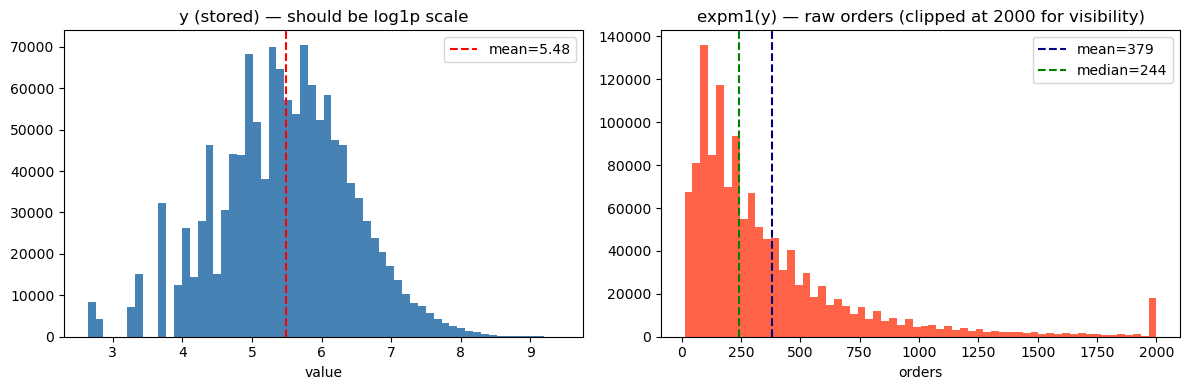

y range:       [2.639, 9.420]  mean=5.484  std=0.968
raw orders:    [13, 12327]  mean=379  median=244
Skewness of raw orders: 5.18  (>1 = right-skewed)


In [3]:
y_train = np.load(SEQ_DIR / 'train_y.npy')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train.ravel(), bins=60, color='steelblue', edgecolor='none')
axes[0].set_title('y (stored) — should be log1p scale')
axes[0].set_xlabel('value')
axes[0].axvline(y_train.mean(), color='red', linestyle='--', label=f'mean={y_train.mean():.2f}')
axes[0].legend()

y_raw = np.expm1(y_train)
axes[1].hist(np.clip(y_raw.ravel(), 0, 2000), bins=60, color='tomato', edgecolor='none')
axes[1].set_title('expm1(y) — raw orders (clipped at 2000 for visibility)')
axes[1].set_xlabel('orders')
axes[1].axvline(y_raw.mean(), color='navy', linestyle='--', label=f'mean={y_raw.mean():.0f}')
axes[1].axvline(np.median(y_raw), color='green', linestyle='--', label=f'median={np.median(y_raw):.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'y range:       [{y_train.min():.3f}, {y_train.max():.3f}]  mean={y_train.mean():.3f}  std={y_train.std():.3f}')
print(f'raw orders:    [{y_raw.min():.0f}, {y_raw.max():.0f}]  mean={y_raw.mean():.0f}  median={np.median(y_raw):.0f}')
print(f'Skewness of raw orders: {pd.Series(y_raw.ravel()).skew():.2f}  (>1 = right-skewed)')

## 3. Feature statistics — all 32 columns at last timestep

In [4]:
X_train = np.load(SEQ_DIR / 'train_X_temporal.npy')
X_last = X_train[:, -1, :]  # last timestep, shape (N, 32)

stats = pd.DataFrame({
    'col': TEMPORAL_COLS,
    'min':  X_last.min(axis=0),
    'mean': X_last.mean(axis=0),
    'std':  X_last.std(axis=0),
    'max':  X_last.max(axis=0),
    'p99':  np.percentile(X_last, 99, axis=0),
}).set_index('col').round(3)

# Flag columns with extreme outliers (max > 5 std devs)
stats['outlier_flag'] = stats['max'].abs() > 5
print(stats.to_string())

                          min   mean    std        max    p99  outlier_flag
col                                                                        
num_orders             -0.617  0.274  1.114  29.500000  4.700          True
checkout_price         -1.801 -0.235  0.945   2.615000  2.297         False
base_price             -1.863 -0.237  0.977   2.375000  2.070         False
discount_rate          -3.407 -0.029  0.944   6.672000  3.059          True
log_checkout_price     -3.438 -0.238  0.976   1.867000  1.724         False
emailer_for_promotion  -0.294  0.016  1.024   3.396000  3.396         False
homepage_featured      -0.344  0.026  1.032   2.909000  2.909         False
email_x_discount       -3.638  0.026  1.039   8.664000  4.835          True
homepage_x_discount    -4.858  0.025  1.021   8.672000  4.836          True
week_number            -0.939  0.235  0.656   1.317000  1.317         False
week_of_year_sin       -1.406 -0.205  1.005   1.440000  1.440         False
week_of_year

## 4. The outlier problem — demand features vs price/promo features

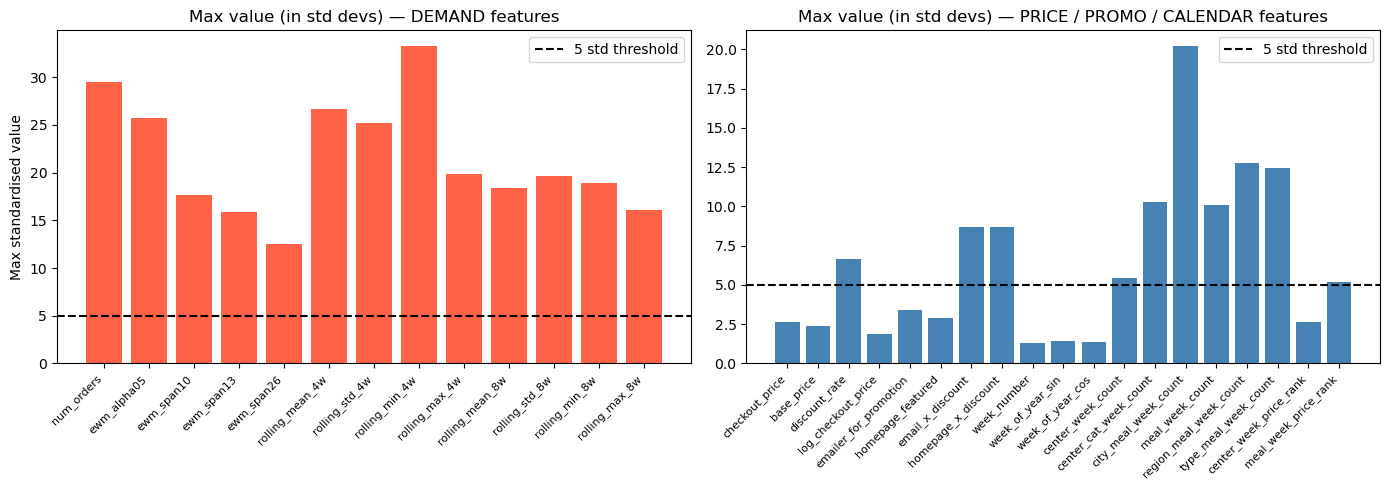

Demand features MAX values (standardised): {'num_orders': np.float32(29.5), 'ewm_alpha05': np.float32(25.7), 'ewm_span10': np.float32(17.7), 'ewm_span13': np.float32(15.8), 'ewm_span26': np.float32(12.5), 'rolling_mean_4w': np.float32(26.6), 'rolling_std_4w': np.float32(25.2), 'rolling_min_4w': np.float32(33.2), 'rolling_max_4w': np.float32(19.8), 'rolling_mean_8w': np.float32(18.4), 'rolling_std_8w': np.float32(19.6), 'rolling_min_8w': np.float32(18.9), 'rolling_max_8w': np.float32(16.1)}


In [5]:
demand_idx = [TEMPORAL_COLS.index(c) for c in DEMAND_COLS]
other_idx  = [i for i in range(32) if i not in demand_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_vals_demand = X_last[:, demand_idx].max(axis=0)
max_vals_other  = X_last[:, other_idx].max(axis=0)

axes[0].bar(range(len(DEMAND_COLS)), max_vals_demand, color='tomato')
axes[0].axhline(5, color='black', linestyle='--', label='5 std threshold')
axes[0].set_xticks(range(len(DEMAND_COLS)))
axes[0].set_xticklabels(DEMAND_COLS, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Max value (in std devs) — DEMAND features')
axes[0].set_ylabel('Max standardised value')
axes[0].legend()

other_names = [TEMPORAL_COLS[i] for i in other_idx]
axes[1].bar(range(len(other_names)), max_vals_other, color='steelblue')
axes[1].axhline(5, color='black', linestyle='--', label='5 std threshold')
axes[1].set_xticks(range(len(other_names)))
axes[1].set_xticklabels(other_names, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Max value (in std devs) — PRICE / PROMO / CALENDAR features')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Demand features MAX values (standardised):',
      dict(zip(DEMAND_COLS, max_vals_demand.round(1))))

## 5. Root cause: demand features were standardised from RAW orders, not log1p orders

The target `y` is `log1p(orders)`. If the input `num_orders` had also been log-transformed before standardisation, the max would be ~4 std devs. Instead it reaches ~30 std devs because the raw demand distribution is highly right-skewed.

**LSTM tanh/sigmoid gates saturate above ±4 — values up to 33 std devs push the model into saturation for every high-demand sample, forcing it to predict near the mean and systematically underpredict.**

In [13]:
# Simulate what log1p-then-standardise would have looked like
num_orders_scaled = X_last[:, 0]  # already standardised raw demand

# Approximate raw demand: recover by inverting standardisation using scaler_params
with open(PROCESSED_DIR / 'scaler_params.json') as f:
    scaler = json.load(f)

print('Available scaler keys (first 20):', list(scaler.keys())[:20])
print()

# Check if num_orders has scaler params
if 'num_orders' in scaler:
    mu  = scaler['num_orders'].mean()
    std = scaler['num_orders'].std
    raw = num_orders_scaled * std + mu
    log_transformed = np.log1p(np.clip(raw, 0, None))
    log_mu  = log_transformed.mean()
    log_std = log_transformed.std()
    log_std_scaled = (log_transformed - log_mu) / log_std

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(np.clip(num_orders_scaled, -5, 35), bins=80, color='tomato', edgecolor='none')
    axes[0].set_title(f'num_orders (current) — max={num_orders_scaled.max():.1f} std devs')
    axes[0].set_xlabel('standardised value')

    axes[1].hist(np.clip(log_std_scaled, -5, 10), bins=80, color='steelblue', edgecolor='none')
    axes[1].set_title(f'log1p(num_orders) re-standardised — max={log_std_scaled.max():.1f} std devs')
    axes[1].set_xlabel('standardised value')

    plt.tight_layout()
    plt.show()
    print(f'Current:          max={num_orders_scaled.max():.2f}  p99={np.percentile(num_orders_scaled, 99):.2f}')
    print(f'After log1p fix:  max={log_std_scaled.max():.2f}  p99={np.percentile(log_std_scaled, 99):.2f}')
else:
    print('num_orders not in scaler_params — checking what keys exist...')
    print(list(scaler.keys()))

Available scaler keys (first 20): ['lag_10', 'lag_11', 'lag_12', 'lag_13', 'rolling_mean_4w', 'rolling_std_4w', 'rolling_min_4w', 'rolling_max_4w', 'rolling_mean_8w', 'rolling_std_8w', 'rolling_min_8w', 'rolling_max_8w', 'ewm_span10', 'ewm_span13', 'ewm_span26', 'ewm_alpha05', 'discount_rate', 'log_checkout_price', 'emailer_for_promotion', 'homepage_featured']



AttributeError: 'list' object has no attribute 'mean'

## 6. LSTM saturation effect

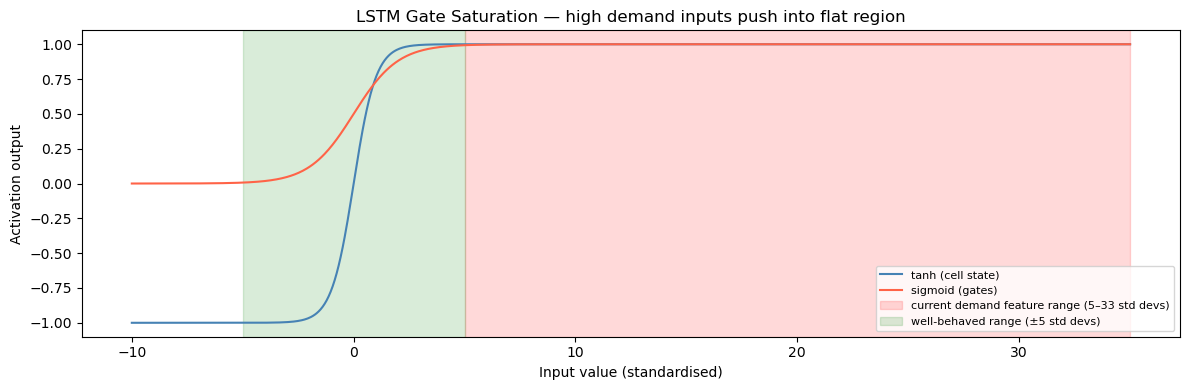

In [7]:
x = np.linspace(-10, 35, 1000)
tanh_out = np.tanh(x)
sigmoid_out = 1 / (1 + np.exp(-np.clip(x, -500, 500)))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(x, tanh_out,    label='tanh (cell state)', color='steelblue')
ax.plot(x, sigmoid_out, label='sigmoid (gates)',   color='tomato')
ax.axvspan(5, 35, alpha=0.15, color='red', label='current demand feature range (5–33 std devs)')
ax.axvspan(-5, 5, alpha=0.15, color='green', label='well-behaved range (±5 std devs)')
ax.set_xlabel('Input value (standardised)')
ax.set_ylabel('Activation output')
ax.set_title('LSTM Gate Saturation — high demand inputs push into flat region')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Scaler parameters inspection

In [14]:
with open(PROCESSED_DIR / 'scaler_params.json') as f:
    scaler = json.load(f)

rows = []
for k, v in scaler.items():
    if isinstance(v, dict):
        rows.append({'feature': k, 'mean': v.get('mean', None), 'std': v.get('std', None)})
    else:
        rows.append({'feature': k, 'mean': v, 'std': None})

df_scaler = pd.DataFrame(rows)
print(df_scaler.to_string(index=False))

               feature                                        mean  std
                lag_10     [269.6136355502108, 414.71773924180366] None
                lag_11    [269.15294450290264, 412.83646829415375] None
                lag_12    [269.30533067050345, 412.66595077968896] None
                lag_13     [269.0387756708971, 412.43504589678656] None
       rolling_mean_4w      [266.3307229853611, 348.3218783128194] None
        rolling_std_4w    [111.28018031162618, 228.19545228040855] None
        rolling_min_4w    [162.37266808384888, 227.41989019842796] None
        rolling_max_4w     [403.84090064154503, 601.9386417113832] None
       rolling_mean_8w    [266.52004972401426, 319.28466346884767] None
        rolling_std_8w     [133.0045529722596, 231.77396447658973] None
        rolling_min_8w    [131.73467106291943, 188.72221089160018] None
        rolling_max_8w     [511.64635895115435, 734.2485404470976] None
            ewm_span10     [265.11179941254903, 313.407960799859

## 8. Correlation between features and target

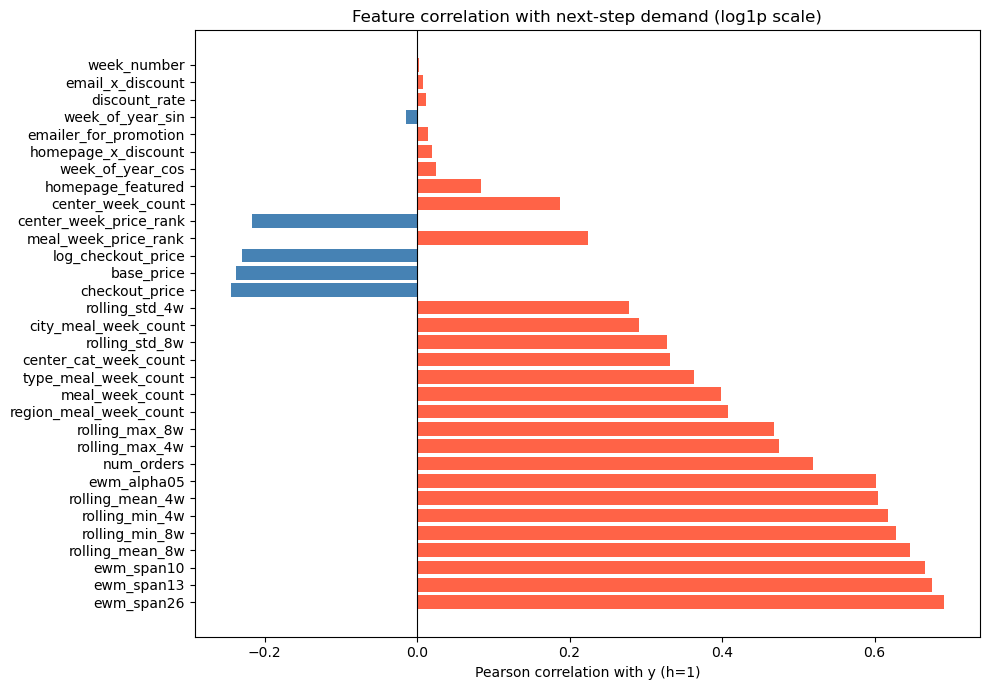

               feature  corr_with_y_h1
            ewm_span26        0.691493
            ewm_span13        0.675256
            ewm_span10        0.665652
       rolling_mean_8w        0.646533
        rolling_min_8w        0.628756
        rolling_min_4w        0.617807
       rolling_mean_4w        0.604533
           ewm_alpha05        0.601400
            num_orders        0.518992
        rolling_max_4w        0.474780
        rolling_max_8w        0.467581
region_meal_week_count        0.407258
       meal_week_count        0.398728
  type_meal_week_count        0.362543
 center_cat_week_count        0.331694
        rolling_std_8w        0.327427
  city_meal_week_count        0.290320
        rolling_std_4w        0.277412
        checkout_price       -0.244876
            base_price       -0.237324
    log_checkout_price       -0.229375
  meal_week_price_rank        0.224576
center_week_price_rank       -0.216301
     center_week_count        0.187389
     homepage_featured   

In [15]:
X_last = X_train[:, -1, :]
y_h1   = y_train[:, 0]  # h=1 target

corrs = np.array([np.corrcoef(X_last[:, i], y_h1)[0, 1] for i in range(32)])
corr_df = pd.DataFrame({'feature': TEMPORAL_COLS, 'corr_with_y_h1': corrs})\
            .sort_values('corr_with_y_h1', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if c > 0 else 'steelblue' for c in corr_df['corr_with_y_h1']]
ax.barh(corr_df['feature'], corr_df['corr_with_y_h1'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with y (h=1)')
ax.set_title('Feature correlation with next-step demand (log1p scale)')
plt.tight_layout()
plt.show()

print(corr_df.to_string(index=False))

## 9. Diagnosis summary and fix recommendation

| Issue | Evidence | Fix |
|---|---|---|
| Demand features up to 33 std devs | `num_orders` max=29.5, `rolling_min_4w` max=33.2 | Apply `log1p` to demand features **before** standardising in `features.py` |
| LSTM gate saturation | All values >5 push tanh/sigmoid into flat region | Fixed by the log1p preprocessing |
| Target y already in log1p | y range 2.6–9.4 | Input features should be in same conceptual scale |
| Price/promo features well-behaved | max 2–10 std devs | No change needed for these |

**Required change in `features.py`**: apply `np.log1p` to all demand-derived columns (`num_orders`, `ewm_*`, `rolling_*`) before fitting the z-score scaler. Then re-run sequence generation and retrain.

In [16]:
# Quick check: what would the effective input range look like after fixing?
print('=== Current (broken) effective input ranges ===')
for c in DEMAND_COLS:
    i = TEMPORAL_COLS.index(c)
    v = X_last[:, i]
    print(f'  {c:<25}  p99={np.percentile(v,99):6.1f}  max={v.max():6.1f}')

print()
print('Target: all features should have p99 < 5 and max < 10 for healthy LSTM training')

=== Current (broken) effective input ranges ===
  num_orders                 p99=   4.7  max=  29.5
  ewm_alpha05                p99=   4.6  max=  25.7
  ewm_span10                 p99=   4.5  max=  17.7
  ewm_span13                 p99=   4.4  max=  15.8
  ewm_span26                 p99=   4.4  max=  12.5
  rolling_mean_4w            p99=   4.5  max=  26.6
  rolling_std_4w             p99=   5.4  max=  25.2
  rolling_min_4w             p99=   4.9  max=  33.2
  rolling_max_4w             p99=   4.9  max=  19.8
  rolling_mean_8w            p99=   4.5  max=  18.4
  rolling_std_8w             p99=   5.1  max=  19.6
  rolling_min_8w             p99=   4.8  max=  18.9
  rolling_max_8w             p99=   4.8  max=  16.1

Target: all features should have p99 < 5 and max < 10 for healthy LSTM training
